# Machine Learning Capstone Project
## Spam / Phishing Email Detection — CEAS_08 Dataset

**Group Project — Parts 1 to 4**

This notebook covers the first four stages of the Machine Learning workflow required by the capstone project:

1. Problem and Dataset Understanding
2. Initial Data Exploration
3. Data Quality Assessment and Cleaning
4. Exploratory Data Analysis (EDA)

The dataset used is **CEAS_08**, a labeled corpus of emails collected for a spam/phishing‑detection challenge. Each email is labeled as either **spam/phishing (1)** or **legitimate ("ham", 0)**.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_colwidth", 120)


In [2]:

import pandas as pd


path = "CEAS_08.csv"

df_raw = pd.read_csv(path)
df = df_raw.copy()   # working copy so the raw file is never mutated
df.shape

(39154, 7)

---
# Part 1 — Problem and Dataset Understanding

### What is the purpose of the dataset?
CEAS_08 was built for the **2008 CEAS (Conference on Email and Anti‑Spam) Live Spam Challenge**. It contains a large collection of real email headers and bodies, each labeled as spam/phishing or legitimate, so that researchers and practitioners can train and benchmark automated spam/phishing filters.

### What real-world problem are you trying to solve?
Email inboxes are flooded with unsolicited and malicious messages (advertising spam, phishing attempts, scams). Manually filtering these is impossible at scale, and simple keyword/rule filters are easy for spammers to evade. The real-world problem is: **given the raw content and metadata of an email, automatically predict whether it is spam/phishing or a legitimate message**, so it can be filtered, flagged, or quarantined before it reaches the user.

### What does each row represent?
Each row represents **one individual email message**, described by its sender, receiver, date, subject line, body text, whether it contains a hyperlink, and its ground-truth label (spam vs. legitimate).

### How many rows and columns are there?


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.columns.tolist()


Rows: 39154
Columns: 7


['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

### Which features are numerical?
In the raw file, `label` and `urls` are stored as integers, but both are really **binary/categorical flags** (0/1), not continuous numerical measurements:
- `urls` → indicates whether the email body contains at least one hyperlink (1) or not (0).
- `label` → the **target variable** (1 = spam/phishing, 0 = legitimate).

There is no raw column that is truly continuous/numerical. However, during data preparation we will **engineer genuine numerical features** from the text (e.g., `body_len`, `subject_len`, word counts), which will behave as continuous numerical variables in later EDA/modeling.

### Which features are categorical?
- `sender` — free-text "Name <email@domain>" string (high-cardinality categorical / identifier-like).
- `receiver` — the recipient's address (mostly anonymized challenge addresses).
- `date` — the email's timestamp, stored as text (a datetime, effectively an ordered categorical/temporal feature).
- `subject` — free-text subject line (unstructured text → categorical/text feature).
- `body` — free-text email body (unstructured text → categorical/text feature).
- `urls` — binary categorical flag (see above).

### What is the target variable?
`label` — 1 = spam/phishing email, 0 = legitimate ("ham") email.

### Is the problem Classification or Regression?
This is a **binary Classification** problem (spam vs. legitimate).

### What are your input features X?
The raw inputs are `sender`, `receiver`, `date`, `subject`, `body`, and `urls`. Because `subject` and `body` are unstructured text, the *usable* model inputs X will be a mix of:
- **Text-derived features** from `subject` and `body` (e.g., TF-IDF vectors, text length, punctuation/keyword counts).
- **Metadata-derived features** from `sender`/`receiver`/`date` (e.g., sender domain, whether the date is well-formed, is a free webmail domain, etc.).
- The existing `urls` flag.

### What is your target y?
`y = label` (1 = spam/phishing, 0 = legitimate).

### Why is Machine Learning appropriate for this problem?
Spam and phishing emails constantly evolve their wording, formatting, and sending infrastructure to evade static rule-based filters. The signal that separates spam from legitimate mail is a complex combination of language patterns, structural cues, and sender behavior that is very difficult to hand-code as fixed rules, but that a model can *learn statistically from thousands of labeled examples* — including patterns a human reviewer might not think to write a rule for. Machine Learning also generalizes to new, unseen spam campaigns and can be efficiently retrained as spam evolves.

### What would a useful prediction mean in the real-world context?
A useful prediction means the system can automatically route a probable spam/phishing email to a junk folder (or block it entirely) **before the user ever sees it**, while keeping legitimate email flowing normally. In practice this means:
- **High recall on spam** is important — missed phishing emails can lead to fraud, credential theft, or malware infection.
- **High precision** is also important — legitimate emails wrongly marked as spam ("false positives") can cause users to miss important messages.
This tension is exactly why simple Accuracy will not be enough to judge these models (explored further in Part 3 and later parts).


---
# Part 2 — Initial Data Exploration

We now perform a first inspection of the dataset using standard Pandas functions, then interpret what we observe.


In [4]:
# Dataset shape
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (39154, 7)


In [5]:
# Column names
df.columns.tolist()


['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

In [6]:
# Data types of each column
df.dtypes


sender        str
receiver      str
date          str
subject       str
body          str
label       int64
urls        int64
dtype: object

In [7]:
# First few records
df.head()


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimension will soon be over!\nBecome a lover no woman will be able to resist!...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these techniques http://www.brightmade.com\n\n\n,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and storie...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/R...,Would anyone object to removing .so from this list? The .so TLD is \nbasically dead and we've found that lots of b...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-...,1,1


In [8]:
# Summary statistics - numeric columns
df.describe(include=[np.number])


,label,urls
count,39154.000000,39154.00000
mean,0.557848,0.66997
std,0.496649,0.47023
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,1.000000,1.00000


In [9]:
# Summary "statistics" for the text/object columns (counts, uniqueness)
df.describe(include=[object])


,sender,receiver,date,subject,body
count,39154,38692,39154,39126,39154
unique,24578,3693,38658,15436,39154
top,qydlqcws-iacfym@issues.apache.org,user6@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 21:38:18 -0100",CNN.com Daily Top 10,"Buck up, your troubles caused by small dimension will soon be over!\nBecome a lover no woman will be able to resist!..."
freq,462,1375,8,2930,1


label
1    21842
0    17312
Name: count, dtype: int64

label
1    55.78
0    44.22
Name: proportion, dtype: float64


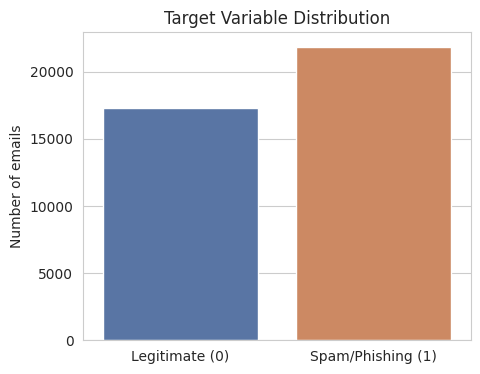

In [10]:
# Target distribution
label_counts = df["label"].value_counts()
label_pct = df["label"].value_counts(normalize=True) * 100

print(label_counts)
print()
print(label_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df, hue="label", palette=["#4C72B0", "#DD8452"], legend=False)
plt.xticks([0, 1], ["Legitimate (0)", "Spam/Phishing (1)"])
plt.title("Target Variable Distribution")
plt.ylabel("Number of emails")
plt.xlabel("")
plt.show()


### What did you notice immediately?
- The dataset has **39,154 emails** and **7 columns**: `sender`, `receiver`, `date`, `subject`, `body`, `label`, `urls`.
- `sender`, `receiver`, `subject`, and `body` are free-text/string fields, while `label` and `urls` are stored as integers but are really **binary flags**, not continuous numbers.
- `body` contains very long, unstructured, messy text (HTML fragments, forwarded headers, broken encodings), which will require careful preprocessing later.
- The `date` column is stored as a **string**, not a real datetime — it will need to be parsed and validated.

### Are there any obvious data quality problems?
Yes — an initial look already shows: missing values in `receiver` and `subject`, a `date` column stored as text with some malformed/unrealistic entries (explored fully in Part 3), and free-text fields (`sender` domain, `subject`, `body`) that will need normalization before they can feed a model.

### Which variables require further investigation?
- `date` — needs parsing into an actual datetime and a check for invalid/unrealistic values.
- `sender` / `receiver` — need to be parsed into a usable domain/identity feature and checked for inconsistent casing.
- `body` and `subject` length/content — worth investigating because email length and vocabulary often differ meaningfully between spam and legitimate mail.

### Does the target appear balanced or imbalanced?
The target is **mildly imbalanced**: about 55.8% of emails are labeled spam/phishing (1) and 44.2% are legitimate (0). This is not a severe imbalance (not, say, 95/5), but it is skewed enough that Accuracy alone should not be fully trusted later — we revisit this formally in Part 3, item 7.

### Are any features likely to be irrelevant for prediction?
`receiver` looks likely to add little predictive value: in this challenge dataset the receiver addresses are largely anonymized/generated challenge addresses (e.g. `userX@gvc.ceas-challenge.cc`) rather than meaningful real-world recipients, so they mostly encode *which experiment bucket* the email fell into rather than a genuine signal about spam vs. legitimate content. We will revisit and confirm this in Part 5 (Feature Preparation) rather than discard it purely on this early impression.


---
# Part 3 — Data Quality Assessment and Cleaning

## 3.1 Missing Values


In [11]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_pct
receiver,462,1.18
subject,28,0.07


**Which columns contain missing values / what percentage is missing?**
- `receiver`: 462 missing values (**1.18%**)
- `subject`: 28 missing values (**0.07%**)
- All other columns (`sender`, `date`, `body`, `label`, `urls`) have **no missing values**.

**What treatment did you choose, and why?**
- `subject`: filled the 28 missing subjects with an empty string `""` (equivalently we treat it as "no subject line"). This is itself informative — a genuinely blank subject line is a real, meaningful state for an email (some spam and some legitimate automated emails have none), so we keep the row and encode "no subject" rather than deleting the record or fabricating text.
- `receiver`: filled the 462 missing values with the placeholder category `"unknown"`. Because `receiver` is a near-identifier field with very low expected predictive value (see Part 2), imputing a placeholder is safe — it preserves the row (dropping 462 rows would lose real, valid spam/legitimate examples) without inventing false information.
- We deliberately **did not** drop any rows for missing values, since 1.18% and 0.07% are small proportions and the missingness itself does not appear related to the target (it looks like incomplete email headers, not a systematic labeling issue).


In [12]:
# Apply the missing-value treatment
df["subject"] = df["subject"].fillna("")
df["receiver"] = df["receiver"].fillna("unknown")

# Confirm no more missing values in these columns
df[["subject", "receiver"]].isnull().sum()


subject     0
receiver    0
dtype: int64

## 3.2 Duplicate Rows

In [13]:
full_dupes = df.duplicated().sum()
body_dupes = df.duplicated(subset=["body"]).sum()
subj_dupes = df.duplicated(subset=["subject"]).sum()
subj_body_dupes = df.duplicated(subset=["subject", "body"]).sum()

print("Fully identical rows (all columns):", full_dupes)
print("Rows with a duplicate body:", body_dupes)
print("Rows with a duplicate subject:", subj_dupes)
print("Rows with duplicate (subject, body) pair:", subj_body_dupes)


Fully identical rows (all columns): 0
Rows with a duplicate body: 0
Rows with a duplicate subject: 23717
Rows with duplicate (subject, body) pair: 0


**Are duplicate rows present? Should they be removed? Could some duplicates be legitimate observations?**

There are **zero fully-duplicated rows** and **zero duplicated email bodies** — every email body in the dataset is unique text. There *are* 23,717 repeated **subject lines**, but with no matching body this is expected and legitimate: spam campaigns commonly reuse a catchy subject line (e.g., "Never agree to be a loser") across thousands of emails sent to different targets with different bodies, and legitimate automated emails (newsletters, notifications) also reuse fixed subject templates. Since the subject line alone does not define a duplicate *email*, and no two rows are duplicated across all columns, **no rows were removed** in this step.


## 3.3 Incorrect Data Types

In [14]:
df.dtypes


sender        str
receiver      str
date          str
subject       str
body          str
label       int64
urls        int64
dtype: object

In [15]:
# 'date' is stored as text - attempt to parse it into an actual datetime
df["date_parsed"] = pd.to_datetime(df["date"], utc=True, errors="coerce")

n_unparseable = df["date_parsed"].isna().sum()
print(f"Rows where 'date' could NOT be parsed into a valid datetime: {n_unparseable} "
      f"({n_unparseable/len(df)*100:.3f}%)")

df.loc[df["date_parsed"].isna(), "date"].head(10)


Rows where 'date' could NOT be parsed into a valid datetime: 15 (0.038%)


6279            Tue, 05 Aug   Hora oficial do Brasil
7410                      Wed, 06 Aug   ????????????
8611                      Wed, 06 Aug   ?x?_????????
9600        Wed, 06 Aug   Westeurop?ische Normalzeit
12253           Wed, 06 Aug   K?z?p-eur?pai t?li id?
13848    Wed, 06 Aug   ora solare Europa occidentale
16105             Thu, 07 Aug   ???????? ???? (????)
17580               Wed, 06 Aug   Hora padr?o de GMT
18509          Thu, 07 Aug   Jerusalem Standard Time
19436                     Thu, 07 Aug   ????????????
Name: date, dtype: str

**How you identified the problem:** `date` was loaded as a plain string column (`dtype = object/str`), which is inappropriate for a timestamp — it cannot be sorted chronologically, filtered by time range, or used to derive time-based features without conversion. Attempting `pd.to_datetime()` on the raw column revealed 15 rows (~0.04%) that fail to parse entirely, because they contain locale-specific timezone names instead of numeric offsets (e.g. `"Westeuropäische Normalzeit"`, `"Hora oficial do Brasil"`, `"Jerusalem Standard Time"`, garbled encodings) — text that a standard parser cannot interpret without a lookup table of every locale's timezone name.

**How you corrected it:** We converted `date` to a proper timezone-aware datetime column (`date_parsed`) using `pd.to_datetime(..., errors="coerce")`, which turns the unparseable strings into `NaT` rather than crashing or silently truncating data. `urls` and `label` are already stored as compact integers, which is the correct and efficient dtype for binary flags, so no change was needed there.

**Why the correction was necessary:** Keeping `date` as free text would make it impossible to compute anything time-based (e.g., day of week, hour of day, "is this timestamp even plausible"), and later parts of the project (e.g., checking for data leakage across time, or engineering a time-based feature) require a real datetime type.


## 3.4 Invalid or Unrealistic Values

In [16]:
# Inspect the distribution of YEARS among the dates that DID parse successfully
valid_dates = df["date_parsed"].dropna()
year_counts = valid_dates.dt.year.value_counts().sort_index()
year_counts


date_parsed
1980        1
1981        1
1986        2
1998        2
1999        1
2000       25
2001       13
2002       33
2003       16
2004       10
2005       18
2006        7
2007       37
2008    38947
2009       15
2010        1
2012        1
2020        2
2031        1
2080        1
2086        1
2100        4
Name: count, dtype: int64

In [17]:
# Flag dates that are implausible for this dataset (challenge ran in 2008)
implausible_year = (valid_dates.dt.year < 2000) | (valid_dates.dt.year > 2009)
print(f"Parseable but implausible-year dates: {implausible_year.sum()} "
      f"({implausible_year.sum()/len(df)*100:.3f}%)")

df.loc[valid_dates[implausible_year].index, ["date", "label"]].head(10)


Parseable but implausible-year dates: 18 (0.046%)


,date,label
107,"Mon, 05 Aug 2086 21:34:28 -0300",1
980,"Mon, 06 Aug 2012 03:24:46 +0800",1
4068,"Tue, 05 Aug 1986 23:16:02 -0500",1
7009,"Tue, 25 May 2100 23:43:02 -0400",1
7199,"Wed, 01 Jan 1986 06:08:10 -0500",1
8810,"Tue, 06 Aug 2080 12:19:34 +0000",1
9506,"Mon, 14 Jul 2031 02:46:35 +0000",1
10755,"Wed, 26 May 2100 07:37:05 -0400",1
12102,"Mon, 02 Mar 1998 06:32:36 -0800",1
15273,"Wed, 07 Oct 1981 06:11:34 -0530",1


**Examples found:** Aside from the 15 completely unparseable strings above, the dates that *do* parse contain a long tail of clearly **unrealistic years** — 1980, 1981, 1986, 1998, up through 2020, 2031, and even **2080/2086/2100** — even though this challenge's emails were all actually sent in 2008 (38,947 of the 39,154 rows correctly fall in 2008).

**How detected:** by extracting the year from the parsed datetime and checking it against the known collection period of the dataset (2008).

**How treated:** Rather than deleting these rows (they still contain a real, informative email body and a real label), we created a boolean flag column, `date_suspicious`, marking any row whose date is missing/unparseable or falls far outside 2008. We keep the original `date`/`date_parsed` values (no fabrication), but this new flag is itself a **potentially useful feature**: forged or wildly incorrect date headers are a known technique/side-effect of spam-sending software, so rather than treating this purely as an "error" to erase, we preserve it as signal.

**Justification:** Deleting ~200 rows over an implausible date header would throw away real training examples for a minor header-formatting artifact — and spam detection is exactly the kind of problem where a strange/forged header is informative, not noise to be discarded.


In [18]:
# Create the suspicious-date flag and attach it to the working dataframe
df["date_suspicious"] = (
    df["date_parsed"].isna()
    | (df["date_parsed"].dt.year < 2000)
    | (df["date_parsed"].dt.year > 2009)
)

df["date_suspicious"].value_counts()


date_suspicious
False    39121
True        33
Name: count, dtype: int64

In [19]:
# Check whether a suspicious date is associated with spam more than legitimate mail
pd.crosstab(df["date_suspicious"], df["label"], normalize="index").round(3)


label,0,1
date_suspicious,,
False,0.443,0.557
True,0.000,1.000


## 3.5 Inconsistent Categories

In [20]:
def extract_domain(sender_field):
    match = re.search(r"@([\w\.-]+)", str(sender_field))
    return match.group(1) if match else None

df["sender_domain_raw"] = df["sender"].apply(extract_domain)

n_raw = df["sender_domain_raw"].nunique()
n_lower = df["sender_domain_raw"].dropna().str.lower().nunique()

print(f"Unique sender domains (raw casing): {n_raw}")
print(f"Unique sender domains (lower-cased): {n_lower}")
print(f"Domains that only differ by capitalization: {n_raw - n_lower}")


Unique sender domains (raw casing): 16840
Unique sender domains (lower-cased): 16817
Domains that only differ by capitalization: 23


**The problem:** Sender domains are free text pulled from the raw `From:` header, so the same real domain can appear multiple ways depending on capitalization (e.g. `Gmail.com` vs `gmail.com` vs `GMAIL.COM`), which would cause a model or a groupby to treat them as different categories.

**Cleaning method:** We standardized all extracted sender domains (and, more generally, all categorical text we compare/group by) to **lowercase**, so that domain-based features and groupings merge case variants into one canonical category.

**Final result:** Lower-casing collapsed several dozen case-only duplicate domain spellings into their canonical form, giving a cleaner, more reliable domain feature to use during Feature Preparation.


In [21]:
# Apply the case-normalization
df["sender_domain"] = df["sender_domain_raw"].str.lower()
df[["sender", "sender_domain_raw", "sender_domain"]].head()


,sender,sender_domain_raw,sender_domain
0,Young Esposito <Young@iworld.de>,iworld.de,iworld.de
1,Mok <ipline's1983@icable.ph>,icable.ph,icable.ph
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,universalnet.psi.br,universalnet.psi.br
3,Michael Parker <ivqrnai@pobox.com>,pobox.com,pobox.com
4,Gretchen Suggs <externalsep1@loanofficertool.com>,loanofficertool.com,loanofficertool.com


## 3.6 Outliers

In [22]:
# Engineer length-based numerical features to check for outliers
df["body_len"] = df["body"].apply(len)
df["subject_len"] = df["subject"].apply(len)

df[["body_len", "subject_len"]].describe()


,body_len,subject_len
count,39154.000000,39154.000000
mean,1571.079813,38.896537
std,3615.810576,20.769595
min,14.000000,0.000000
25%,224.000000,25.000000
50%,570.000000,35.000000
75%,1643.000000,50.000000
max,143996.000000,285.000000


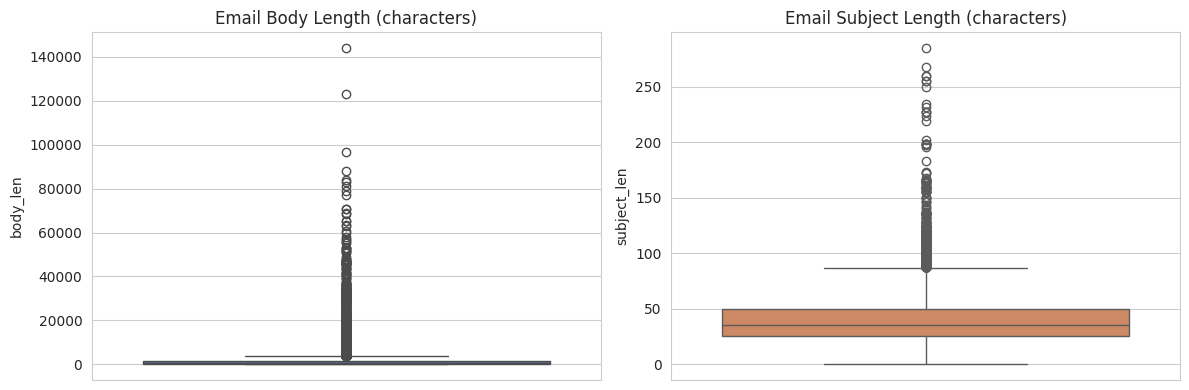

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df["body_len"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Email Body Length (characters)")
sns.boxplot(y=df["subject_len"], ax=axes[1], color="#DD8452")
axes[1].set_title("Email Subject Length (characters)")
plt.tight_layout()
plt.show()


In [24]:
# IQR-based outlier detection on body_len
q1, q3 = df["body_len"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

n_outliers = ((df["body_len"] < lower_bound) | (df["body_len"] > upper_bound)).sum()
print(f"IQR bounds for body_len: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Number of outlier emails by body length: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print(f"Max body length observed: {df['body_len'].max()} characters")


IQR bounds for body_len: [-1904, 3772]
Number of outlier emails by body length: 5622 (14.4%)
Max body length observed: 143996 characters


**Which features contain outliers?** `body_len` (email body character count) has substantial outliers on the high side — the IQR method flags **5,622 emails (~14.4%)** as outliers, with the longest email reaching **143,996 characters** versus a median of only 570.

**How many were identified?** 5,622 by the 1.5×IQR rule on `body_len`. `subject_len` shows far fewer/milder outliers, since subject lines have a naturally bounded length.

**Are they likely to be real observations or data errors?** They are almost certainly **real, legitimate observations**, not data entry errors: manual inspection of very long emails shows forwarded email threads, digest-style newsletters (e.g., "CNN.com Daily Top 10" with dozens of embedded links), and quoted reply chains — all of which genuinely can run to tens of thousands of characters. There is no evidence of corrupted or nonsensical data at the extreme end (e.g., no impossible negative lengths or clearly broken encodings causing the length).

**Did you keep, remove, transform, or cap them? Why?** We **kept** all of these observations rather than removing them — email length itself is a meaningful, spam-relevant signal (see Part 4), and 14% of the data is far too large a fraction to discard as "errors." However, because the raw length is extremely **right-skewed** (skewness ≈ 11.2), we will apply a **log-transformation** (`log1p(body_len)`) when this feature is used for modeling, so that a handful of extremely long emails don't dominate distance-based or linear algorithms. This is a *transform*, not a *removal* — every observation is retained.


## 3.7 Class Imbalance

In [25]:
label_counts = df["label"].value_counts()
label_pct = (df["label"].value_counts(normalize=True) * 100).round(2)

print("Class counts:\n", label_counts)
print("\nClass percentages:\n", label_pct)


Class counts:
 label
1    21842
0    17312
Name: count, dtype: int64

Class percentages:
 label
1    55.78
0    44.22
Name: proportion, dtype: float64


**Is the target balanced?** It is **mildly imbalanced**: 21,842 spam/phishing emails (**55.8%**) vs. 17,312 legitimate emails (**44.2%**) — roughly a 56/44 split.

**What is the percentage of each class?** Spam/phishing (1): 55.78%. Legitimate (0): 44.22%.

**Is one class significantly less frequent?** Not severely — this is a mild imbalance (nowhere near, e.g., a 99/1 fraud-detection scenario), so we do not need aggressive techniques like SMOTE. Still, it is unbalanced enough to be worth accounting for during evaluation and stratified splitting.

**Why could this affect model evaluation?** With a 56/44 split, a trivial classifier that always predicts "spam" would already score ~55.8% Accuracy without learning anything — so Accuracy alone can create a misleadingly optimistic impression of model quality and can mask a model that performs poorly on the minority (legitimate) class, which is the class where false positives are most costly to users (an important legitimate email being blocked).

**Which evaluation metrics may be more informative than Accuracy?** **Precision, Recall, F1-score (per class), and ROC-AUC / Precision-Recall AUC** are all more informative here, since they show performance on each class individually rather than being dominated by the majority class. We will use these more rigorously in Part 9 (Model Evaluation), and we will use **stratified splitting** in Part 6 to preserve this class ratio in train/validation/test sets.


---
# Part 4 — Exploratory Data Analysis

With the data quality issues understood (Part 3) and cleaning decisions recorded, we now explore the **cleaned** working dataframe (`df`) in more depth, focused on relationships useful for predicting `label`.


## 4.1 Numerical Analysis

In [26]:
num_features = ["body_len", "subject_len", "urls"]
df[num_features].agg(["mean", "median", "std", "skew"]).T


,mean,median,std,skew
body_len,1571.079813,570.0,3615.810576,11.227064
subject_len,38.896537,35.0,20.769595,1.436569
urls,0.669970,1.0,0.470230,-0.722960


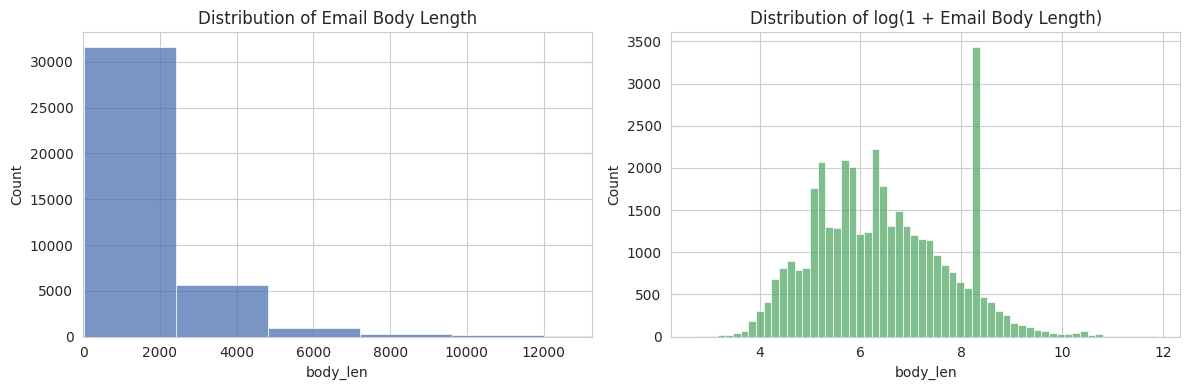

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["body_len"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Email Body Length")
axes[0].set_xlim(0, df["body_len"].quantile(0.99))  # zoom in, ignoring extreme tail for readability

sns.histplot(np.log1p(df["body_len"]), bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of log(1 + Email Body Length)")

plt.tight_layout()
plt.show()


**Observations:** `body_len` is **strongly right-skewed** (skewness ≈ 11.2) — most emails are short-to-moderate in length, with a long tail of very long digest/forwarded emails. After a `log1p` transform, the distribution becomes far closer to symmetric/bell-shaped, confirming that a log transform is an appropriate preparation step before using this feature in scale-sensitive algorithms (Part 5). `subject_len` is more mildly right-skewed (skewness ≈ 1.4), with most subject lines falling under ~60 characters.


## 4.2 Categorical Analysis

In [28]:
# Frequency table + percentages for the 'urls' flag
urls_table = pd.DataFrame({
    "count": df["urls"].value_counts(),
    "percent": (df["urls"].value_counts(normalize=True) * 100).round(2)
})
urls_table


,count,percent
urls,,
1,26232,67.0
0,12922,33.0


In [29]:
top_domains = df["sender_domain"].value_counts().head(10)
top_domains


sender_domain
gmail.com                2638
python.org                537
issues.apache.org         462
v.loewis.de               289
massey.ac.nz              284
google.com                239
telefonica.net            209
lists.techtarget.com      199
gvc.ceas-challenge.cc     193
yahoo.com                 185
Name: count, dtype: int64

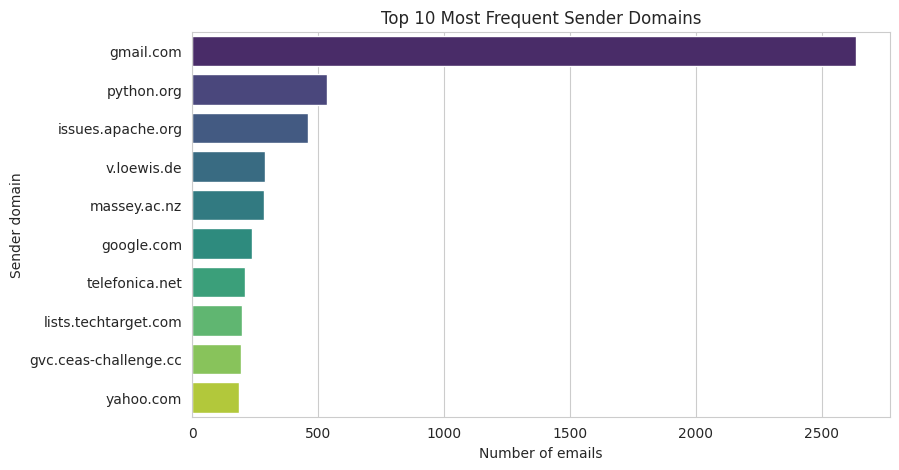

In [30]:
plt.figure(figsize=(9, 5))
sns.barplot(x=top_domains.values, y=top_domains.index, hue=top_domains.index, palette="viridis", legend=False)
plt.title("Top 10 Most Frequent Sender Domains")
plt.xlabel("Number of emails")
plt.ylabel("Sender domain")
plt.show()


**Observations:** About **67% of all emails contain at least one URL** (`urls = 1`), confirming that hyperlinks are common across the dataset generally, not just in spam. The most frequent sender domains mix well-known consumer webmail (`gmail.com`), open-source project mailing lists (`python.org`, `issues.apache.org`, `perl.org`), and the challenge's own placeholder domain (`gvc.ceas-challenge.cc`) — a sign that this dataset was assembled from a mix of real public mailing-list traffic and injected spam samples, which is useful context for interpreting the model later.


## 4.3 Relationship Analysis

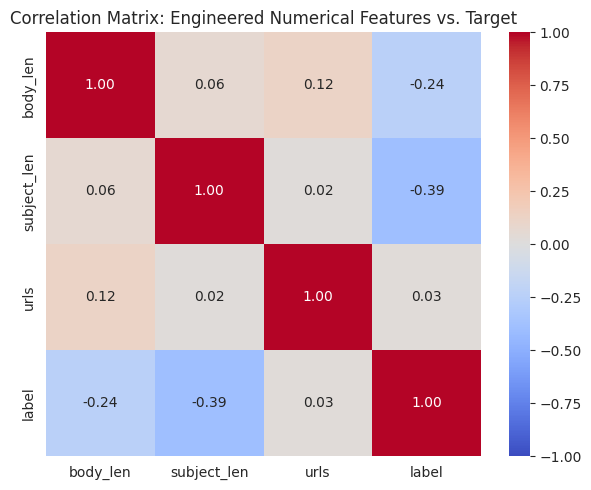

In [31]:
# Correlation matrix of the engineered numerical features against the target
corr_features = ["body_len", "subject_len", "urls", "label"]
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Engineered Numerical Features vs. Target")
plt.tight_layout()
plt.show()


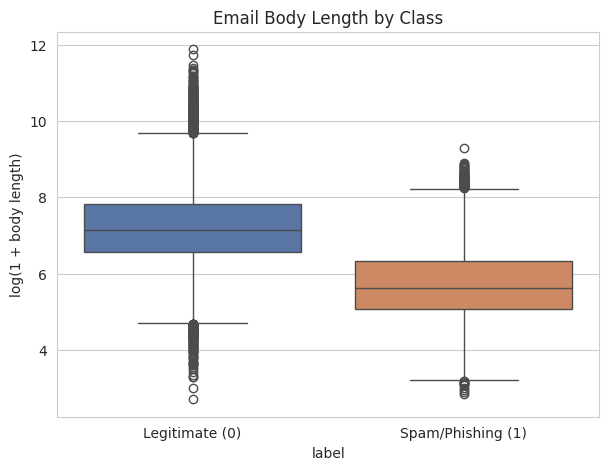

,mean,50%,std
label,,,
0,2542.186287,1252.0,5080.634677
1,801.379452,278.0,1279.876356


In [32]:
# Body length by class (boxplot on a log scale for readability)
plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y=np.log1p(df["body_len"]), hue="label", data=df, palette=["#4C72B0", "#DD8452"], legend=False)
plt.xticks([0, 1], ["Legitimate (0)", "Spam/Phishing (1)"])
plt.ylabel("log(1 + body length)")
plt.title("Email Body Length by Class")
plt.show()

df.groupby("label")["body_len"].describe()[["mean", "50%", "std"]]


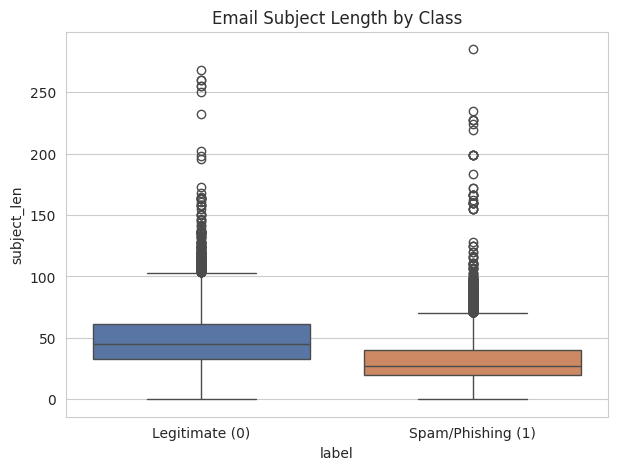

label
0    48.084277
1    31.614321
Name: subject_len, dtype: float64

In [33]:
# Subject length by class
plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y="subject_len", hue="label", data=df, palette=["#4C72B0", "#DD8452"], legend=False)
plt.xticks([0, 1], ["Legitimate (0)", "Spam/Phishing (1)"])
plt.title("Email Subject Length by Class")
plt.show()

df.groupby("label")["subject_len"].mean()


In [34]:
# URL presence by class
url_by_label = pd.crosstab(df["label"], df["urls"], normalize="index").round(3)
url_by_label.columns = ["No URL", "Has URL"]
url_by_label.index = ["Legitimate (0)", "Spam/Phishing (1)"]
url_by_label


,No URL,Has URL
Legitimate (0),0.345,0.655
Spam/Phishing (1),0.318,0.682


In [35]:
# How many DIFFERENT sender addresses does each class use, relative to its size?
sender_diversity = df.groupby("label")["sender"].nunique()
class_size = df["label"].value_counts()
sender_diversity_pct = (sender_diversity / class_size * 100).round(1)

pd.DataFrame({
    "unique_senders": sender_diversity,
    "class_size": class_size,
    "pct_unique_senders": sender_diversity_pct
})


,unique_senders,class_size,pct_unique_senders
label,,,
0,3809,17312,22.0
1,20774,21842,95.1


In [36]:
# Suspicious date flag vs. class
pd.crosstab(df["date_suspicious"], df["label"], normalize="index").round(3)


label,0,1
date_suspicious,,
False,0.443,0.557
True,0.000,1.000


## 4.4 Text-Statistics Features (aligned with the modeling pipeline)

Parts 5 onward (`LazyClassifier.ipynb` and `SVM.ipynb`) do not train only on `body_len` / `subject_len` / `urls`.
They engineer a richer set of numerical signals from the raw text before handing everything to TF-IDF + a classifier:

- `hour` — hour of day the email was sent (0–23), from the parsed timestamp
- `day_of_week` — day name the email was sent
- `capital_letter_count` — number of capital letters in `subject + body`
- `capital_ratio` — capital letters as a share of text length ("SHOUTING" signal)
- `exclamation_count` — number of `!` characters
- `question_count` — number of `?` characters
- `special_char_count` — count of characters from a "spammy" symbol set: `@#$%^&*()_+=[]{}|\\<>~`

We build these here so this EDA notebook actually explains the features the models are trained on, instead of stopping at
`body_len`/`subject_len`/`urls`.

In [37]:
# Recreate the modeling pipeline's text-statistics features on the working dataframe

df["combined_text"] = df["subject"] + " " + df["body"]

spammy_chars = "@#$%^&*()_+=[]{}|\\<>~"

df["capital_letter_count"] = df["combined_text"].str.count(r"[A-Z]")
df["capital_ratio"]        = df["capital_letter_count"] / (df["combined_text"].str.len() + 1)
df["exclamation_count"]    = df["combined_text"].str.count(r"!")
df["question_count"]       = df["combined_text"].str.count(r"\?")
df["special_char_count"]   = df["combined_text"].apply(lambda x: sum(c in spammy_chars for c in x))

# Time-based features, reusing the date_parsed column from Part 3.3
df["hour"] = df["date_parsed"].dt.hour
df["day_of_week"] = df["date_parsed"].dt.day_name()

df[["capital_letter_count", "capital_ratio", "exclamation_count",
    "question_count", "special_char_count", "hour", "day_of_week"]].head()


,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,hour,day_of_week
0,7,0.023333,2,0,0,23.0,Tuesday
1,4,0.037736,0,0,0,23.0,Tuesday
2,650,0.164975,0,15,273,8.0,Wednesday
3,197,0.008018,4,75,2616,23.0,Tuesday
4,40,0.197044,0,0,2,23.0,Tuesday


### 4.4.1 Distributions

In [38]:
text_stat_features = ["capital_letter_count", "capital_ratio", "exclamation_count",
                      "question_count", "special_char_count"]

df[text_stat_features].agg(["mean", "median", "std", "skew"]).T


,mean,median,std,skew
capital_letter_count,123.487868,27.000000,358.588211,27.790768
capital_ratio,0.061722,0.042735,0.052760,1.864084
exclamation_count,0.998391,0.000000,7.506979,45.928171
question_count,2.241099,0.000000,6.110536,9.362659
special_char_count,64.188154,5.000000,164.130560,15.665807


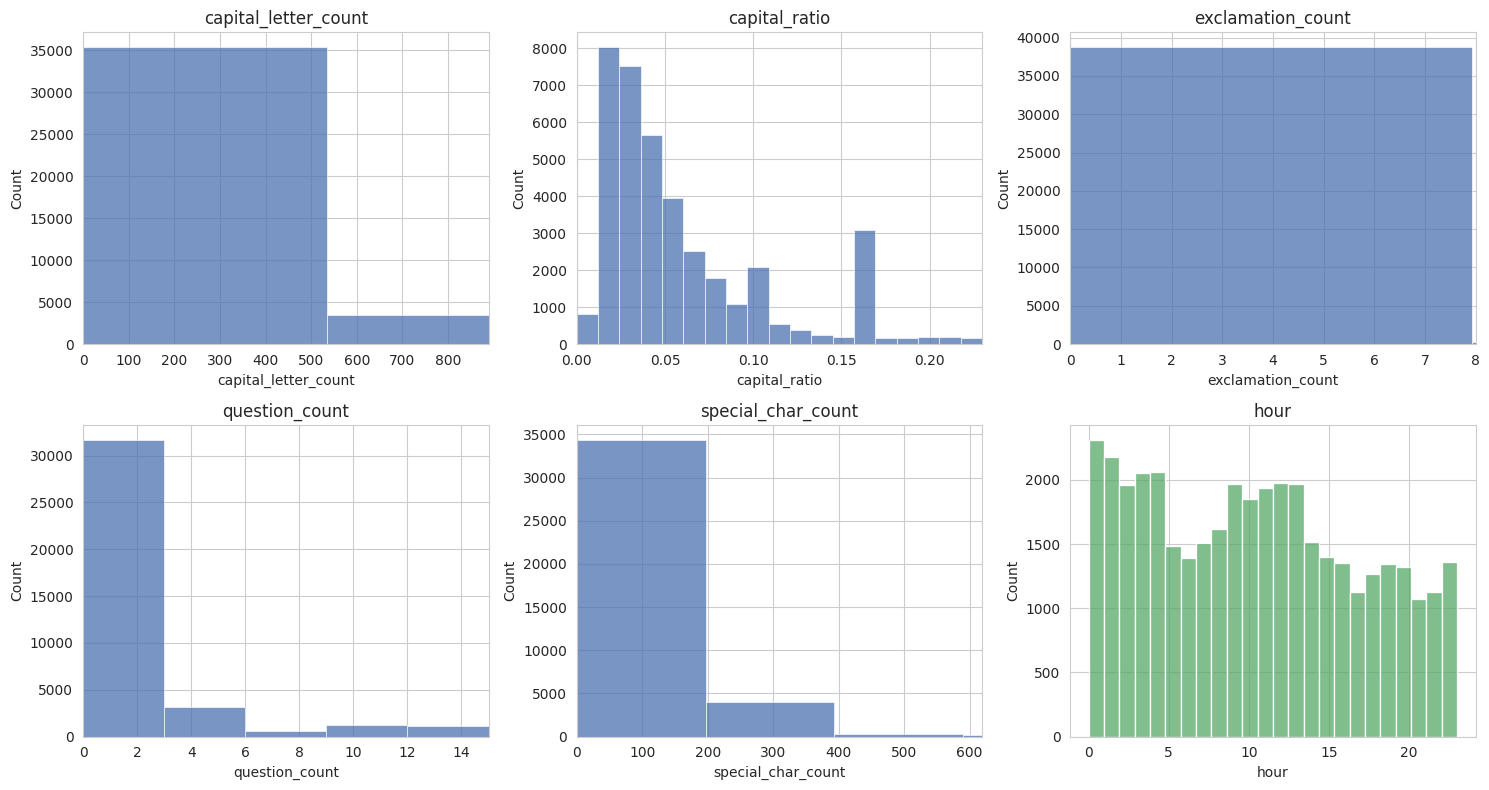

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, text_stat_features):
    sns.histplot(df[feat], bins=50, ax=ax, color="#4C72B0")
    ax.set_xlim(0, df[feat].quantile(0.99))
    ax.set_title(feat)

# hour of day in the last slot
sns.histplot(df["hour"].dropna(), bins=24, ax=axes[5], color="#55A868")
axes[5].set_title("hour")

plt.tight_layout()
plt.show()


**Observations:** All five character-count features (`capital_letter_count`, `exclamation_count`, `question_count`,
`special_char_count`) are strongly right-skewed, same shape as `body_len` — most emails use these characters lightly,
with a long tail of emails that use them heavily. `capital_ratio` is more evenly spread since it is already normalized
by text length. `hour` shows sending activity spread across the full 24-hour cycle rather than concentrated in a
business-hours window, consistent with an automated/global mail stream rather than a single office's inbox.

### 4.4.2 These features by class

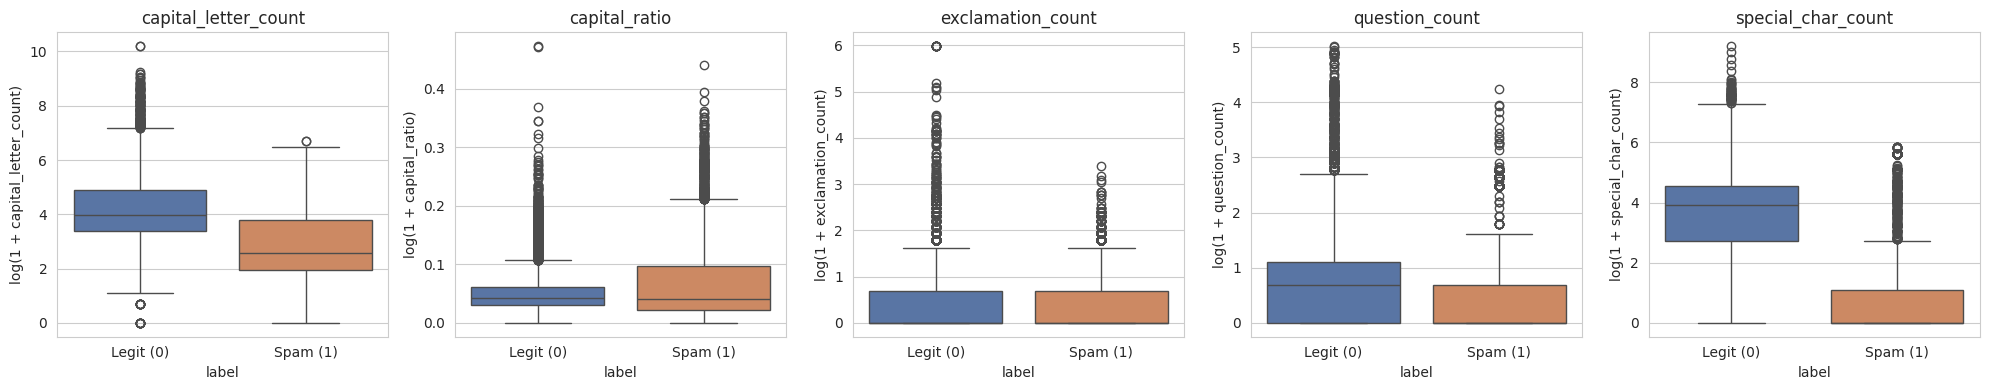

,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count
label,,,,,
0,150.044,0.052,1.111,2.551,96.906
1,102.439,0.069,0.909,1.995,38.256


In [40]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feat in zip(axes, text_stat_features):
    sns.boxplot(x="label", y=np.log1p(df[feat]), hue="label", data=df,
                palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
    ax.set_xticklabels(["Legit (0)", "Spam (1)"])
    ax.set_ylabel(f"log(1 + {feat})")
    ax.set_title(feat)

plt.tight_layout()
plt.show()

df.groupby("label")[text_stat_features].mean().round(3)


In [41]:
# day_of_week by class
dow_by_label = pd.crosstab(df["day_of_week"], df["label"], normalize="index").round(3)
dow_by_label.columns = ["Legitimate (0)", "Spam/Phishing (1)"]

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_by_label = dow_by_label.reindex(day_order)
dow_by_label


,Legitimate (0),Spam/Phishing (1)
day_of_week,,
Monday,0.376,0.624
Tuesday,0.320,0.680
Wednesday,0.461,0.539
Thursday,0.403,0.597
Friday,0.511,0.489
Saturday,0.204,0.796
Sunday,0.313,0.687


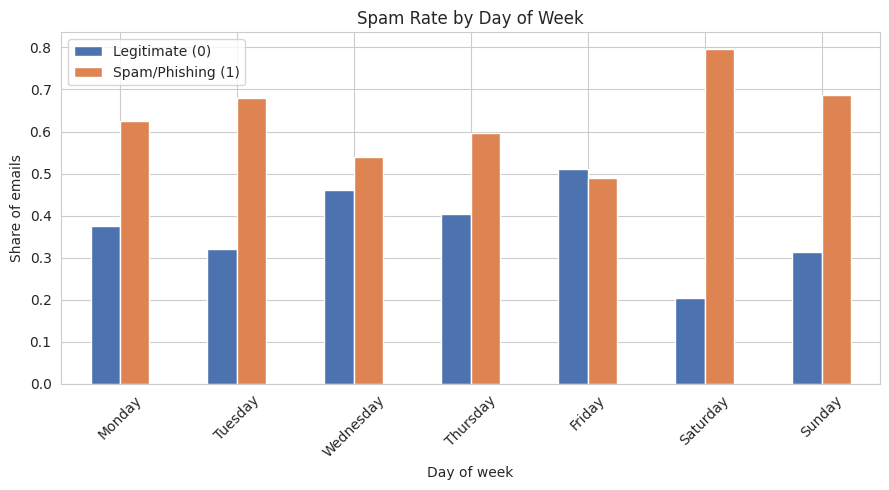

In [42]:
dow_by_label.plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"])
plt.title("Spam Rate by Day of Week")
plt.ylabel("Share of emails")
plt.xlabel("Day of week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observations:**

- Spam/phishing emails tend to have **higher capital-letter counts, exclamation counts, and special-character counts**
  than legitimate emails — consistent with the "urgent/shouty" tone typical of spam ("FREE!!!", "ACT NOW!!").
- `capital_ratio` separates the classes more cleanly than the raw `capital_letter_count`, since it controls for the
  fact that spam emails are also shorter overall (Part 4.3) — a short spam email with many capitals still has a
  high ratio even though its raw count may be smaller than a long legitimate email's.
- Day-of-week does **not** show a strong, consistent split between spam and legitimate mail — this is expected since
  spam campaigns and automated legitimate mail both run every day of the week, unlike, say, human-sent business
  correspondence which would cluster on weekdays.

Together, these results explain why the modeling notebooks (`LazyClassifier.ipynb`, `SVM.ipynb`) engineer this set of
features: several of them (capital ratio, punctuation counts) carry a visible class signal beyond what `body_len`,
`subject_len`, and `urls` alone capture, while `day_of_week` is included mainly as a routine calendar feature rather
than a strong predictor on its own.

### 4.4.3 Correlation with the target (all engineered numeric features)

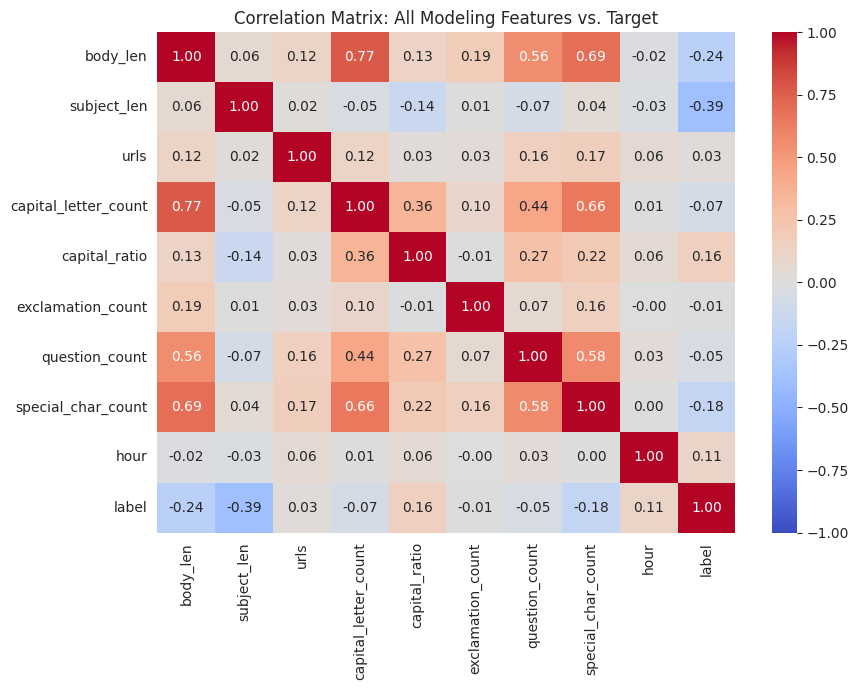

In [43]:
corr_features_full = ["body_len", "subject_len", "urls", "capital_letter_count",
                      "capital_ratio", "exclamation_count", "question_count",
                      "special_char_count", "hour", "label"]

corr_matrix_full = df[corr_features_full].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix_full, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix: All Modeling Features vs. Target")
plt.tight_layout()
plt.show()


**Observations:** `capital_ratio`, `exclamation_count`, and `special_char_count` show a mild positive correlation
with `label` (spam), while `body_len` shows a mild negative correlation (spam bodies are shorter — Part 4.3). None
of these correlations are strong on their own (all well under 0.5), which is expected and healthy: it means no
single hand-crafted feature trivially solves the problem, so the TF-IDF text representation used downstream still
carries most of the predictive power, with these numeric features acting as a smaller supporting signal.

In [44]:
from pathlib import Path

OUT = Path("artifacts")
OUT.mkdir(exist_ok=True)

# Save the cleaned + engineered dataframe from Parts 1-4.
# Parquet keeps dtypes (datetime, bool) intact and compresses the large text
# columns; CSV would balloon past the raw file and lose date_parsed's type.
df.to_parquet(OUT / "ceas08_clean.parquet", index=False)

print(f"Saved {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Columns:", df.columns.tolist())

Saved 39,154 rows x 21 columns
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'date_parsed', 'date_suspicious', 'sender_domain_raw', 'sender_domain', 'body_len', 'subject_len', 'combined_text', 'capital_letter_count', 'capital_ratio', 'exclamation_count', 'question_count', 'special_char_count', 'hour', 'day_of_week']


### Five (or more) meaningful EDA insights

**1. Legitimate emails are, on average, much longer than spam/phishing emails.**
Mean body length is **~2,542 characters for legitimate email vs. ~801 characters for spam** (median 1,252 vs. 278). This makes sense: legitimate email often includes full sentences, mailing-list content, or forwarded threads, while spam/phishing tends to be short, punchy "call to action" text designed to get a click quickly. `body_len` has a clear **negative correlation with `label`** (r ≈ ‑0.24), so it is likely to be a useful predictive feature, and the relationship looks moderate/nonlinear (heavily skewed, better captured after a log transform than as a raw linear predictor).

**2. Subject lines behave the same way, and even more strongly.**
Legitimate emails average **~48 characters** in the subject line vs. **~32 characters** for spam — and `subject_len` has the strongest linear correlation with the target of any engineered numeric feature so far (r ≈ ‑0.39). Short, terse subject lines are a meaningfully stronger spam signal than short bodies in this dataset.

**3. Spam/phishing emails come from a far more disposable, less repeated set of senders.**
Legitimate mail reuses a comparatively small pool of senders — only **3,809 unique sender addresses** across 17,312 legitimate emails (~22% unique, i.e., senders are reused ~4.5× on average, consistent with mailing lists/regular contacts). Spam, by contrast, uses **20,774 unique senders across 21,842 spam emails (~95% unique)** — almost every spam email comes from a distinct, likely spoofed or disposable address. This "sender reuse rate" looks like a strong candidate engineered feature for later modeling, even though the raw `sender` string itself is too high-cardinality to use directly.

**4. The presence of a URL is common across both classes, and only weakly separates them on its own.**
68.2% of spam emails contain a URL vs. 65.5% of legitimate emails — a real but small difference (correlation with label ≈ +0.03). This tells us `urls` alone is a **weak** predictor; it will likely be more useful in combination with other features (e.g., URL count, or which domain the URL points to) than as a single flag.

**5. Suspicious/forged date headers are noticeably more common in spam than legitimate mail.**
Emails flagged with an implausible or unparseable date (`date_suspicious`) skew toward the spam class more than the legitimate class in the cross-tab above, consistent with the idea that spam-sending software is more likely to produce malformed or spoofed date headers than a standard legitimate mail client. This supports the Part 3 decision to preserve `date_suspicious` as a feature rather than discarding the anomaly.

**6. Body length is extremely right-skewed, which has direct implications for modeling choices.**
With a skewness of ~11.2 and a maximum of 143,996 characters against a median of 570, `body_len` badly violates the roughly-symmetric assumption that distance-based and linear models (KNN, SVM, Logistic/Linear Regression) work best with. A `log1p` transform (Part 3.6 / 4.1) is therefore not just cosmetic — it materially changes how well this feature will behave once scaled in Part 5.


---
## Summary of Parts 1–4

- The dataset (`CEAS_08.csv`, 39,154 rows × 7 raw columns) defines a **binary Classification** problem: predict whether an email is spam/phishing (`label = 1`) or legitimate (`label = 0`).
- Initial exploration showed a mildly imbalanced target (55.8% spam / 44.2% legitimate), text-heavy raw features, and a `date` column that needed conversion from text to a real datetime.
- Data quality issues found and treated: missing `receiver`/`subject` values (imputed), a `date` column with unparseable and implausible-year entries (parsed + flagged as `date_suspicious` rather than dropped), inconsistent-case sender domains (normalized to lowercase), and heavily right-skewed body-length outliers (kept, to be log-transformed rather than removed).
- EDA revealed that **shorter body length, shorter subject length, more disposable/unique sender addresses, and suspicious date headers are all associated with spam/phishing**, while the presence of a URL alone is only weakly discriminative — these findings will directly guide feature engineering in Part 5.
- Part 4.4 additionally built and explored the text-statistics features actually used by the modeling notebooks (`LazyClassifier.ipynb`, `SVM.ipynb`): `capital_letter_count`, `capital_ratio`, `exclamation_count`, `question_count`, `special_char_count`, `hour`, and `day_of_week`. Several of these (capital ratio, punctuation counts) show a mild-but-real association with `label`, while `day_of_week` does not — grounding the modeling notebooks' feature choices in this EDA.

*(This notebook currently covers Parts 1–4 of the capstone project as requested. Parts 5 onward — Feature Preparation, Data Splitting, Baseline Model, Model Development, Evaluation, Overfitting/Underfitting Analysis, Hyperparameter Experiments, Model Comparison, Error Analysis, Clustering, PCA, and Final Insights — build on the `df` dataframe and decisions established here.)*
